In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
data=pd.read_excel("/content/customer churn analysis.xlsx")

load data set from csv to dataframe

In [3]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0.0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0.0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0.0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0.0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0.0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Insight:
We can see that there are some numerical and categorical columns


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7047 entries, 0 to 7046
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7047 non-null   object 
 1   gender            7041 non-null   object 
 2   SeniorCitizen     7041 non-null   float64
 3   Partner           7047 non-null   object 
 4   Dependents        7047 non-null   object 
 5   tenure            7044 non-null   float64
 6   PhoneService      7045 non-null   object 
 7   MultipleLines     7047 non-null   object 
 8   InternetService   7045 non-null   object 
 9   OnlineSecurity    7047 non-null   object 
 10  OnlineBackup      7044 non-null   object 
 11  DeviceProtection  7047 non-null   object 
 12  TechSupport       7047 non-null   object 
 13  StreamingTV       7047 non-null   object 
 14  StreamingMovies   7047 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7047 non-null   object 


Insight: Data has three numerical columns and 16 categorical columns  
problem :
1. TotalCharges has data type object but it should numeric  
2. SeniorCitizen has numerical value it should Yes or No categorical value


In [5]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7041.000000,7044.000000,7047.000000
mean,0.162051,32.378478,64.809344
std,0.368524,24.561539,30.213982
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.525000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,214.650000


In [6]:
data.describe(include=object)

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7047,7041,7047,7047,7045,7047,7045,7047,7044,7047,7047,7047,7047,7043,7047,7044,7047,7047
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,4132-KALRO,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,2,3555,3642,4935,6362,3390,3095,3501,3090,3096,3474,2813,2785,3872,4173,2365,11,5178


# Checking Null Values

In [7]:
data.isnull().sum()

,0
customerID,0
gender,6
SeniorCitizen,6
Partner,0
Dependents,0
tenure,3
PhoneService,2
MultipleLines,0
InternetService,2
OnlineSecurity,0


9 columns has null values

## Handling Null Values

In [8]:
round(data.isnull().sum()/len(data)*100,2)

,0
customerID,0.00
gender,0.09
SeniorCitizen,0.09
Partner,0.00
Dependents,0.00
tenure,0.04
PhoneService,0.03
MultipleLines,0.00
InternetService,0.03
OnlineSecurity,0.00


In [9]:
#  for numerical coulumn with outlier
def handel_null_with_outlier_num(data,column):
  data[column].fillna(data[column].median(),inplace=True)


In [10]:
#  for numerical coulumn
def handel_null_num(data,column):
  data[column].fillna(data[column].mean(),inplace=True)

In [11]:
#  for caterorical coulumn
def handel_null_cat(data,column):
  data[column].fillna(data[column].mode()[0],inplace=True)

In [12]:
# Gender column
handel_null_cat(data,"gender")
data["gender"].isnull().sum()

np.int64(0)

In [13]:
#  SeniorCitizen column
handel_null_cat(data,"SeniorCitizen")
data["SeniorCitizen"].isnull().sum()

np.int64(0)

In [14]:
#  tenure column
handel_null_num(data,"tenure")
data["tenure"].isnull().sum()

np.int64(0)

In [15]:
# PhoneService column
handel_null_cat(data,"PhoneService")
data["PhoneService"].isnull().sum()

np.int64(0)

In [16]:
handel_null_cat(data,"InternetService")
data["InternetService"].isnull().sum()

np.int64(0)

In [17]:
handel_null_cat(data,"OnlineBackup")
data["OnlineBackup"].isnull().sum()

np.int64(0)

In [18]:
handel_null_cat(data,"Contract")
data["Contract"].isnull().sum()

np.int64(0)

In [19]:
handel_null_cat(data,"PaymentMethod")
data["PaymentMethod"].isnull().sum()

np.int64(0)

In [20]:
# handel_null_num(data,"MonthlyCharges")
# data["MonthlyCharges"].isnull().sum()

Now check null value

In [21]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


there are no any null value

fixed SeniorCitizen1 column problem

In [22]:
data["SeniorCitizen"]=data['SeniorCitizen'].astype(dtype=int)

In [23]:
data["SeniorCitizen"].dtype

dtype('int64')

In [24]:
data['SeniorCitizen1']=["Yes" if i==1 else "No" for i in data['SeniorCitizen']]

Create new conditional column with Yes for 1 and No for 0

In [25]:
data.drop(columns="SeniorCitizen",inplace=True)

In [26]:
data.rename(columns={"SeniorCitizen1":"SeniorCitizen"},inplace=True)

In [27]:
data.head()

,customerID,gender,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,SeniorCitizen
0,7590-VHVEG,Female,Yes,No,1.0,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,No
1,5575-GNVDE,Male,No,No,34.0,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.5,No,No
2,3668-QPYBK,Male,No,No,2.0,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,No
3,7795-CFOCW,Male,No,No,45.0,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,No
4,9237-HQITU,Female,No,No,2.0,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,No


# Checking Duplicates

In [28]:
data.duplicated().sum()

np.int64(4)

data set has three duplicates entries

In [29]:
data[data.duplicated()]

,customerID,gender,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,SeniorCitizen
3270,4132-KALRO,Female,No,No,4.0,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Yes,Month-to-month,Yes,Mailed check,100.85,399.25,No,No
6923,7619-PLRLP,Female,Yes,No,53.0,Yes,Yes,DSL,Yes,Yes,...,No,No,Yes,One year,No,Bank transfer (automatic),74.10,3833.95,No,No
7014,5996-EBTKM,Female,Yes,Yes,67.0,Yes,Yes,DSL,No,No,...,Yes,No,Yes,Two year,Yes,Bank transfer (automatic),69.90,4615.9,No,No
7043,5126-RCXYW,Male,Yes,Yes,54.0,No,No phone service,DSL,No,No,...,Yes,No,Yes,Two year,No,Credit card (automatic),46.00,2424.05,No,No


In [30]:
data.drop_duplicates(inplace=True)

In [31]:
data.duplicated().sum()

np.int64(0)

Now data set has no any duplicate entries

# Cheking and Analyzing Outliers

<Axes: >

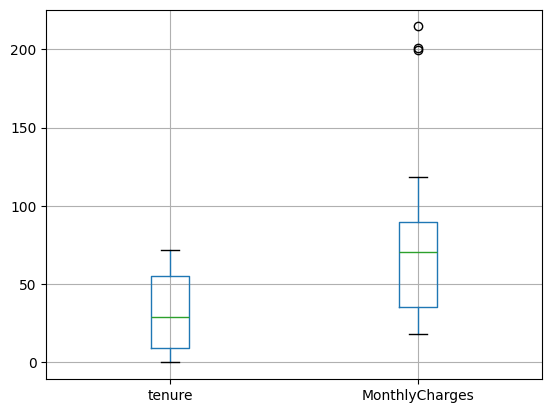

In [32]:
data.boxplot()
# plt.tight_layout()


till now data has two numerical column insted of TotalCharges

In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7046
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   float64
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 
 17  

solve problem :
TotalCharges has data type object but it should numeric


In [34]:
data["TotalCharges"].dtype

dtype('O')

now dtyep of this column is Object

In [35]:
data["TotalCharges"].value_counts()

,count
TotalCharges,
20.2,11
,11
19.75,9
19.65,8
19.9,8
...,...
130.15,1
3211.9,1
7843.55,1


there are empty string value that bcz proble accur

In [36]:
data['TotalCharges'].replace(" ",np.nan,inplace=True)

In [37]:
data[data["TotalCharges"].isnull()]

,customerID,gender,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,SeniorCitizen
488,4472-LVYGI,Female,Yes,Yes,0.0,No,No phone service,DSL,Yes,No,...,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,No
753,3115-CZMZD,Male,No,Yes,0.0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No,No
936,5709-LVOEQ,Female,Yes,Yes,0.0,Yes,No,DSL,Yes,Yes,...,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No,No
1082,4367-NUYAO,Male,Yes,Yes,0.0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No,No
1340,1371-DWPAZ,Female,Yes,Yes,0.0,No,No phone service,DSL,Yes,Yes,...,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No,No
3331,7644-OMVMY,Male,Yes,Yes,0.0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No,No
3826,3213-VVOLG,Male,Yes,Yes,0.0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No,No
4380,2520-SGTTA,Female,Yes,Yes,0.0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No,No
5218,2923-ARZLG,Male,Yes,Yes,0.0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No,No
6670,4075-WKNIU,Female,Yes,Yes,0.0,Yes,Yes,DSL,No,Yes,...,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No,No


In [38]:
data["TotalCharges"]=data["TotalCharges"].astype(float)
data["TotalCharges"].dtype

dtype('float64')

In [39]:
data['TotalCharges'].fillna(data["TotalCharges"].mean(),inplace=True)

Replace that NaN to Mean of own column

In [40]:
data[data['TotalCharges'].isnull()]

,customerID,gender,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,SeniorCitizen


now there are no any null value

**lets check outliers using histogram**

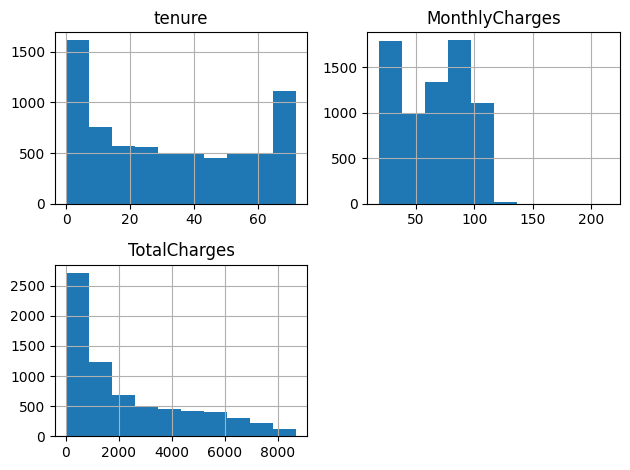

In [41]:
data.hist()
plt.tight_layout()

insigt: TotalCharges may has outliers


# Box Plot

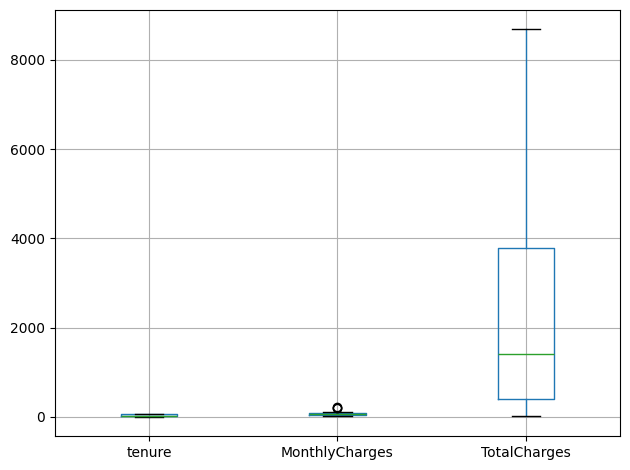

In [42]:
data.boxplot()
plt.tight_layout()

totalcharges has oultliers

In [43]:
#  analyze outliers

def Outlier_ditection(data,column):
  Q1=data[column].quantile(0.25)
  Q3=data[column].quantile(0.75)
  IQR=Q3-Q1
  global LE,UE
  LE=Q1-(1.5*IQR)
  UE=Q3+(1.5*IQR)

Outlier_ditection(data,"MonthlyCharges")

In [44]:
print(UE,LE)

171.375 -46.02499999999999


In [45]:
data[(data['MonthlyCharges']<LE)|(data['MonthlyCharges']>UE)]

,customerID,gender,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,SeniorCitizen
2308,3324-OIRTO,Male,Yes,Yes,71.0,Yes,No,Fiber optic,Yes,Yes,...,No,Yes,Yes,One year,Yes,Bank transfer (automatic),214.65,7288.40,No,No
2483,7641-EUYET,Male,Yes,Yes,46.0,Yes,Yes,Fiber optic,Yes,Yes,...,No,Yes,No,Month-to-month,Yes,Electronic check,200.70,4541.20,Yes,Yes
3085,5052-PNLOS,Male,No,No,3.0,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),199.35,323.25,Yes,No


# Treatment with Outliers

In [46]:
data['MonthlyCharges'].clip(lower=LE,upper=UE,inplace=True)

Text(0.5, 1.0, 'Box Plot (MonthlyCharges)')

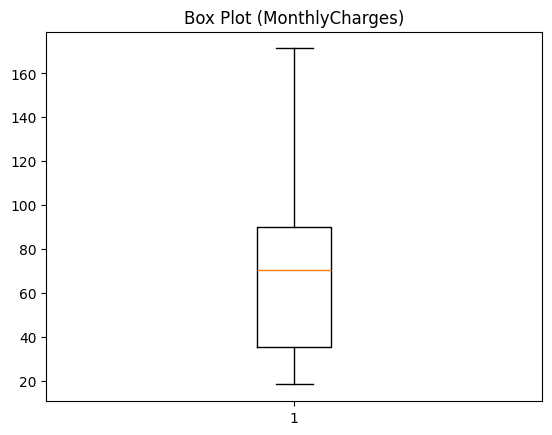

In [49]:
plt.boxplot(data["MonthlyCharges"])
plt.title("Box Plot (MonthlyCharges)")

In [50]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7046
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   float64
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 
 17  

Analys using bar graph

Text(0.5, 1.0, 'Contract by Total Charges')

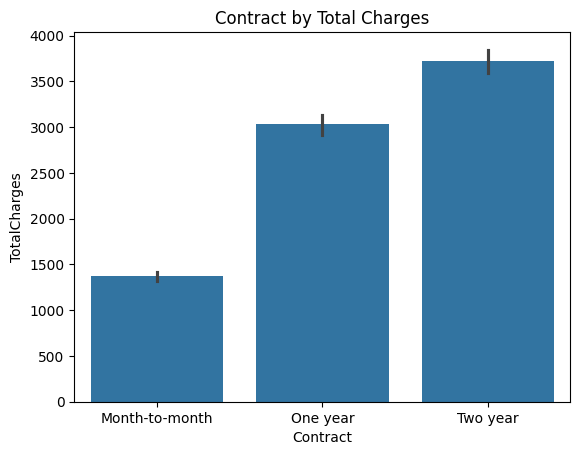

In [ ]:
sns.barplot(x="Contract",y="TotalCharges",data=data)
plt.title("Contract by Total Charges")

Text(0.5, 1.0, 'Male And Female')

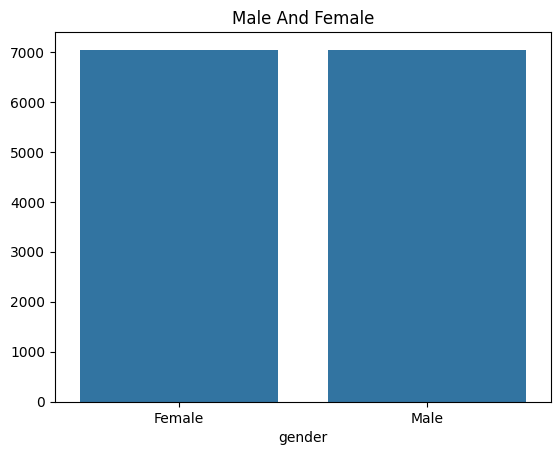

In [ ]:
sns.barplot(x="gender",y=len(data['customerID']),data=data)
plt.title("Male And Female")

([<matplotlib.patches.Wedge at 0x7f7868e1d0a0>,
 [Text(-0.018889607713320523, 1.0998377983686671, 'Male'),
  Text(0.018889703864198335, -1.099837796717281, 'Female')],
 [Text(-0.010303422389083921, 0.5999115263829093, '50.5%'),
  Text(0.010303474835017272, -0.5999115254821532, '49.5%')])

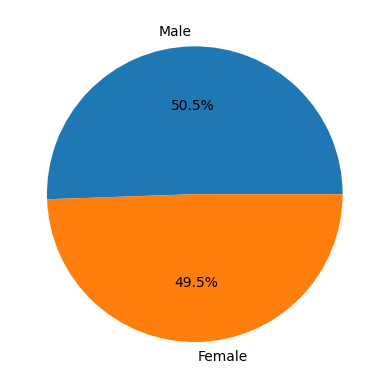

In [62]:
plt.pie(data['gender'].value_counts(),labels=data['gender'].value_counts().index,autopct="%1.1f%%")

In [ ]:
(data['Churn']=="Yes").sum()

np.int64(1869)

In [ ]:
(data['Churn']=="No").sum()

np.int64(5174)

# Checking  Relationships

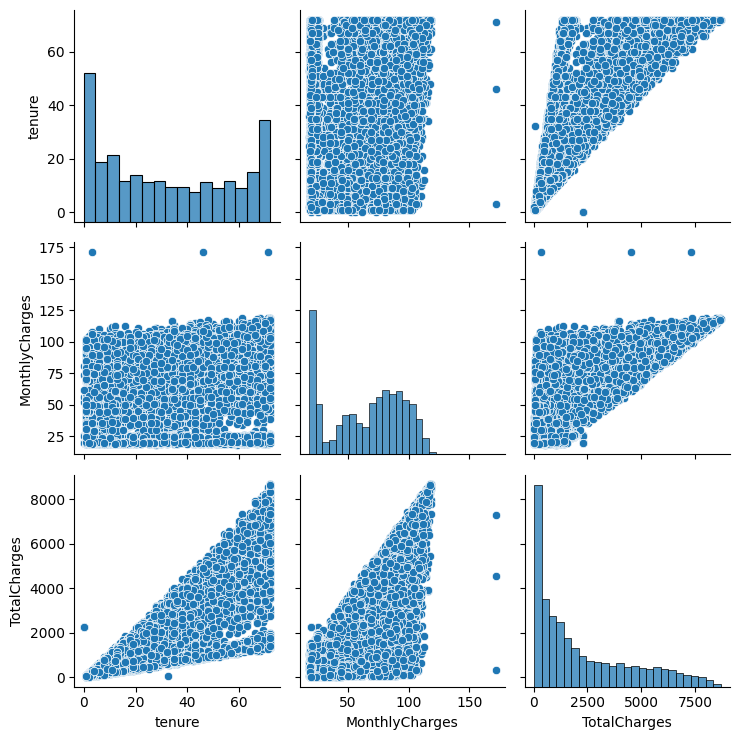

In [ ]:
sns.pairplot(data)
plt.tight_layout()

In [ ]:
data.corr(numeric_only=True)

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247592,0.824661
MonthlyCharges,0.247592,1.000000,0.649722
TotalCharges,0.824661,0.649722,1.000000


<Axes: >

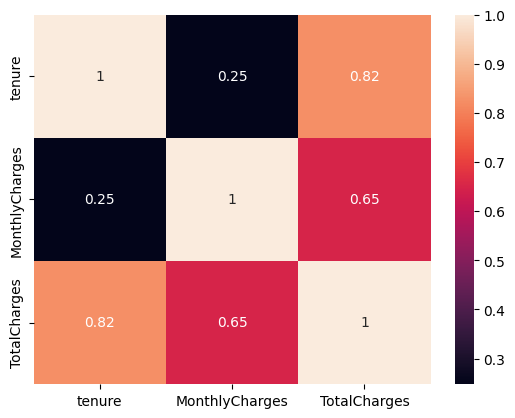

In [55]:
sns.heatmap(data.corr(numeric_only=True),annot=True)

In [64]:
data.to_csv("customer churn analysis (EDA).csv")